# HEDIS Care Gap Outreach Prioritization Using Machine Learning

## Project Overview

This project uses a synthetic healthcare dataset modeled after real HEDIS care gap outreach workflows. The goal is to predict whether a patient is likely to have an unresolved care gap and should be prioritized for outreach.

The dataset is synthetic and does not contain PHI. It was designed based on healthcare quality analytics concepts such as A1c testing, blood pressure control, diabetic eye exams, kidney health evaluation, appointment status, prior emergency utilization, and care gap due dates.

## Business Problem

Healthcare organizations often manage large patient lists with open care gaps. Outreach teams need to know which patients should be contacted first. This model helps prioritize outreach based on clinical indicators, appointment status, utilization history, and measure type.

## Target Variable

care_gap_unresolved:

- 1 = patient likely has an unresolved care gap and needs outreach
- 0 = patient is lower priority or likely already closed the gap

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib joblib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Synthetic Data Creation

Because real patient-level healthcare data contains protected health information, this project uses synthetic data.

The synthetic dataset was designed to reflect common healthcare quality and HEDIS-related workflows, including A1c monitoring, blood pressure control, diabetic eye exams, kidney health evaluation, appointment scheduling, emergency utilization, and care gap due dates.

In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

measure_types = [
    "GSD_A1c",
    "CBP_Blood_Pressure",
    "EED_Eye_Exam",
    "KED_Kidney_Health",
    "PPC_Postpartum_Care",
    "TRC_Medication_Reconciliation"
]

clinic_locations = [
    "Outpatient Medical",
    "Outpatient ID",
    "1419 Myrtle Medicine",
    "Outpatient Pediatrics",
    "OB Clinic",
    "Outpatient Ophthalmology"
]

languages = ["English", "Spanish", "Other"]
genders = ["Male", "Female"]

df = pd.DataFrame({
    "patient_id": range(1, n + 1),
    "age": np.random.randint(18, 81, n),
    "gender": np.random.choice(genders, n, p=[0.48, 0.52]),
    "has_diabetes": np.random.choice([0, 1], n, p=[0.70, 0.30]),
    "clinic_location": np.random.choice(clinic_locations, n),
    "language": np.random.choice(languages, n, p=[0.55, 0.35, 0.10]),
    "has_upcoming_appointment": np.random.choice([0, 1], n, p=[0.55, 0.45]),
    "days_until_due_date": np.random.randint(-30, 120, n),
    "prior_er_visits": np.random.poisson(1.2, n),
    "last_cancelled_appointment": np.random.choice([0, 1], n, p=[0.75, 0.25]),
    "currently_admitted": np.random.choice([0, 1], n, p=[0.92, 0.08])
})

df["diabetes_18_75"] = (
    (df["has_diabetes"] == 1) &
    (df["age"].between(18, 75))
)

def assign_measure(row):
    if row["diabetes_18_75"]:
        return np.random.choice(
            measure_types,
            p=[0.25, 0.20, 0.20, 0.20, 0.05, 0.10]
        )
    else:
        return np.random.choice(
            ["CBP_Blood_Pressure", "PPC_Postpartum_Care", "TRC_Medication_Reconciliation"],
            p=[0.55, 0.20, 0.25]
        )

df["measure_type"] = df.apply(assign_measure, axis=1)

df["a1c_value"] = np.where(
    df["measure_type"] == "GSD_A1c",
    np.round(np.random.normal(8.2, 1.4, n), 1),
    np.nan
)

df["a1c_value"] = df["a1c_value"].clip(lower=5.0, upper=14.0)

df["a1c_category"] = np.select(
    [
        df["a1c_value"] < 8.0,
        df["a1c_value"] > 9.0,
        df["a1c_value"].between(8.0, 9.0)
    ],
    [
        "Controlled (<8.0)",
        "Poor Control (>9.0)",
        "Moderate Control (8.0-9.0)"
    ],
    default=np.nan
)

df["systolic_bp"] = np.where(
    df["measure_type"] == "CBP_Blood_Pressure",
    np.random.randint(105, 180, n),
    np.nan
)

df["diastolic_bp"] = np.where(
    df["measure_type"] == "CBP_Blood_Pressure",
    np.random.randint(65, 110, n),
    np.nan
)

df["bmi"] = np.round(np.random.normal(30, 6, n), 1)

df["egfr_available"] = np.where(
    df["measure_type"] == "KED_Kidney_Health",
    np.random.choice([0, 1], n, p=[0.45, 0.55]),
    np.nan
)

df["microalbumin_available"] = np.where(
    df["measure_type"] == "KED_Kidney_Health",
    np.random.choice([0, 1], n, p=[0.50, 0.50]),
    np.nan
)

df["eye_exam_completed"] = np.where(
    df["measure_type"] == "EED_Eye_Exam",
    np.random.choice([0, 1], n, p=[0.60, 0.40]),
    np.nan
)

df["care_gap"] = np.where(
    (
        (df["measure_type"] == "GSD_A1c") & (df["a1c_value"] > 9.0)
    ) |
    (
        (df["measure_type"] == "EED_Eye_Exam") & (df["eye_exam_completed"] == 0)
    ) |
    (
        (df["measure_type"] == "KED_Kidney_Health") &
        (
            (df["egfr_available"] == 0) |
            (df["microalbumin_available"] == 0)
        )
    ) |
    (
        (df["measure_type"] == "CBP_Blood_Pressure") &
        (
            (df["systolic_bp"] >= 140) |
            (df["diastolic_bp"] >= 90)
        )
    ),
    1,
    0
)

df.head(20)

,patient_id,age,gender,has_diabetes,clinic_location,language,has_upcoming_appointment,days_until_due_date,prior_er_visits,last_cancelled_appointment,...,measure_type,a1c_value,a1c_category,systolic_bp,diastolic_bp,bmi,egfr_available,microalbumin_available,eye_exam_completed,care_gap
0,1,56,Female,1,OB Clinic,Other,1,56,1,1,...,GSD_A1c,6.7,Controlled (<8.0),NaN,NaN,32.1,NaN,NaN,NaN,0
1,2,69,Male,0,Outpatient Medical,Spanish,1,-1,0,1,...,PPC_Postpartum_Care,NaN,nan,NaN,NaN,23.8,NaN,NaN,NaN,0
2,3,46,Male,0,1419 Myrtle Medicine,English,0,27,0,0,...,CBP_Blood_Pressure,NaN,nan,117.0,92.0,28.9,NaN,NaN,NaN,1
3,4,32,Male,0,Outpatient Ophthalmology,Spanish,0,63,1,0,...,CBP_Blood_Pressure,NaN,nan,158.0,89.0,27.4,NaN,NaN,NaN,1
4,5,60,Female,0,Outpatient ID,Spanish,0,10,0,0,...,PPC_Postpartum_Care,NaN,nan,NaN,NaN,35.6,NaN,NaN,NaN,0
5,6,25,Male,0,OB Clinic,Spanish,0,63,0,1,...,CBP_Blood_Pressure,NaN,nan,146.0,68.0,32.8,NaN,NaN,NaN,1
6,7,78,Male,0,1419 Myrtle Medicine,Spanish,1,26,0,0,...,CBP_Blood_Pressure,NaN,nan,144.0,98.0,25.9,NaN,NaN,NaN,1
7,8,38,Male,0,Outpatient Ophthalmology,Spanish,0,33,0,1,...,CBP_Blood_Pressure,NaN,nan,178.0,96.0,26.5,NaN,NaN,NaN,1
8,9,56,Female,0,Outpatient Ophthalmology,English,1,67,1,0,...,PPC_Postpartum_Care,NaN,nan,NaN,NaN,29.8,NaN,NaN,NaN,0
9,10,75,Female,0,Outpatient ID,Spanish,1,-15,3,0,...,CBP_Blood_Pressure,NaN,nan,164.0,86.0,29.0,NaN,NaN,NaN,1


## Data Cleaning and Inspection

The synthetic dataset contains some missing values by design.

For example, A1c values only apply to A1c-related rows, blood pressure values only apply to blood-pressure-related rows, and kidney lab indicators only apply to kidney-health-related rows.

These missing values will be handled later with imputation inside the machine learning pipeline.

In [8]:
df["bmi"] = df["bmi"].clip(18.0, 55.0)
df["prior_er_visits"] = df["prior_er_visits"].clip(0, 8)

df["a1c_category"] = df["a1c_category"].replace("nan", np.nan)

df.head()

,patient_id,age,gender,has_diabetes,clinic_location,language,has_upcoming_appointment,days_until_due_date,prior_er_visits,last_cancelled_appointment,...,measure_type,a1c_value,a1c_category,systolic_bp,diastolic_bp,bmi,egfr_available,microalbumin_available,eye_exam_completed,care_gap
0,1,56,Female,1,OB Clinic,Other,1,56,1,1,...,GSD_A1c,6.7,Controlled (<8.0),NaN,NaN,32.1,NaN,NaN,NaN,0
1,2,69,Male,0,Outpatient Medical,Spanish,1,-1,0,1,...,PPC_Postpartum_Care,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,0
2,3,46,Male,0,1419 Myrtle Medicine,English,0,27,0,0,...,CBP_Blood_Pressure,NaN,NaN,117.0,92.0,28.9,NaN,NaN,NaN,1
3,4,32,Male,0,Outpatient Ophthalmology,Spanish,0,63,1,0,...,CBP_Blood_Pressure,NaN,NaN,158.0,89.0,27.4,NaN,NaN,NaN,1
4,5,60,Female,0,Outpatient ID,Spanish,0,10,0,0,...,PPC_Postpartum_Care,NaN,NaN,NaN,NaN,35.6,NaN,NaN,NaN,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  2000 non-null   int64  
 1   age                         2000 non-null   int64  
 2   gender                      2000 non-null   object 
 3   has_diabetes                2000 non-null   int64  
 4   clinic_location             2000 non-null   object 
 5   language                    2000 non-null   object 
 6   has_upcoming_appointment    2000 non-null   int64  
 7   days_until_due_date         2000 non-null   int64  
 8   prior_er_visits             2000 non-null   int64  
 9   last_cancelled_appointment  2000 non-null   int64  
 10  currently_admitted          2000 non-null   int64  
 11  diabetes_18_75              2000 non-null   bool   
 12  measure_type                2000 non-null   object 
 13  a1c_value                   136 n

In [10]:
df.describe(include="all")

,patient_id,age,gender,has_diabetes,clinic_location,language,has_upcoming_appointment,days_until_due_date,prior_er_visits,last_cancelled_appointment,...,measure_type,a1c_value,a1c_category,systolic_bp,diastolic_bp,bmi,egfr_available,microalbumin_available,eye_exam_completed,care_gap
count,2000.000000,2000.000000,2000,2000.000000,2000,2000,2000.00000,2000.000000,2000.000000,2000.000000,...,2000,136.000000,136,920.000000,920.000000,2000.000000,115.000000,115.000000,100.000000,2000.000000
unique,NaN,NaN,2,NaN,6,3,NaN,NaN,NaN,NaN,...,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,Outpatient ID,English,NaN,NaN,NaN,NaN,...,CBP_Blood_Pressure,NaN,Controlled (<8.0),NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1048,NaN,389,1060,NaN,NaN,NaN,NaN,...,920,NaN,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1000.500000,49.664500,NaN,0.297000,NaN,NaN,0.45450,42.565500,1.187500,0.231000,...,NaN,8.061765,NaN,141.855435,86.822826,30.093150,0.582609,0.443478,0.380000,0.436500
std,577.494589,18.260823,NaN,0.457051,NaN,NaN,0.49805,43.644795,1.080244,0.421578,...,NaN,1.351600,NaN,21.123498,13.073831,5.895865,0.495287,0.498969,0.487832,0.496075
min,1.000000,18.000000,NaN,0.000000,NaN,NaN,0.00000,-30.000000,0.000000,0.000000,...,NaN,5.100000,NaN,105.000000,65.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,34.000000,NaN,0.000000,NaN,NaN,0.00000,3.000000,0.000000,0.000000,...,NaN,7.100000,NaN,124.000000,75.000000,25.800000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,50.000000,NaN,0.000000,NaN,NaN,0.00000,43.000000,1.000000,0.000000,...,NaN,7.950000,NaN,141.000000,87.000000,29.900000,1.000000,0.000000,0.000000,0.000000
75%,1500.250000,66.000000,NaN,1.000000,NaN,NaN,1.00000,80.000000,2.000000,0.000000,...,NaN,8.900000,NaN,160.000000,98.000000,34.000000,1.000000,1.000000,1.000000,1.000000


## Target Variable Creation

The dataset already includes a `care_gap` field based on measure-specific clinical logic.

The machine learning target is `care_gap_unresolved`, which represents whether the patient is likely to still need outreach.

The target is based on:

- Whether a care gap exists
- No upcoming appointment
- Due date overdue or coming soon
- Prior ER utilization
- Cancelled appointment history
- Current admission status

This simulates the operational question: which patients should outreach teams prioritize first?

In [13]:
risk_score = (
    (df["care_gap"] == 1).astype(int) * 3 +
    (df["has_upcoming_appointment"] == 0).astype(int) * 2 +
    (df["days_until_due_date"] <= 14).astype(int) * 2 +
    (df["prior_er_visits"] >= 3).astype(int) * 1 +
    (df["last_cancelled_appointment"] == 1).astype(int) * 1 +
    (df["currently_admitted"] == 1).astype(int) * 1 +
    (df["language"] == "Spanish").astype(int) * 1
)

probability = 1 / (1 + np.exp(-(risk_score - 5)))

df["risk_score"] = risk_score

df["care_gap_unresolved"] = np.where(
    df["care_gap"] == 1,
    np.random.binomial(1, probability),
    0
)

df[["care_gap", "risk_score", "care_gap_unresolved"]].head(10)

,care_gap,risk_score,care_gap_unresolved
0,0,1,0
1,0,4,0
2,1,5,0
3,1,6,1
4,0,5,0
5,1,7,1
6,1,4,0
7,1,7,1
8,0,0,0
9,1,7,1


In [14]:
df["care_gap_unresolved"].value_counts(normalize=True).round(3)

care_gap_unresolved
0    0.74
1    0.26
Name: proportion, dtype: float64

In [15]:
df["care_gap_unresolved"].value_counts()

care_gap_unresolved
0    1479
1     521
Name: count, dtype: int64

In [16]:
df.to_csv("synthetic_hedis_care_gap_data.csv", index=False)

print("Synthetic dataset saved successfully.")

Synthetic dataset saved successfully.


## Feature Preparation

The model uses numeric and categorical features.

Missing values are expected because some clinical fields only apply to certain HEDIS measures.

For example:

- A1c values apply to GSD/A1c rows
- Blood pressure values apply to CBP rows
- Kidney lab indicators apply to KED rows
- Eye exam completion applies to EED rows

The pipeline handles missing values using imputation.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df.drop(columns=[
    "patient_id",
    "care_gap_unresolved",
    "risk_score"
])

y = df["care_gap_unresolved"]

categorical_features = [
    "gender",
    "measure_type",
    "clinic_location",
    "language",
    "a1c_category"
]

numeric_features = [
    "age",
    "has_diabetes",
    "diabetes_18_75",
    "has_upcoming_appointment",
    "days_until_due_date",
    "prior_er_visits",
    "last_cancelled_appointment",
    "currently_admitted",
    "a1c_value",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "egfr_available",
    "microalbumin_available",
    "eye_exam_completed",
    "care_gap"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Features and target prepared.")

Features and target prepared.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1600
Testing rows: 400


## Model Training

Three classification models were trained:

1. Logistic Regression — baseline interpretable model
2. Random Forest — tree-based model that captures nonlinear patterns
3. Gradient Boosting — boosting model often used for tabular prediction problems

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline
    
    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


## Model Evaluation

For healthcare outreach prioritization, recall is especially important.

A false negative means the model incorrectly labels a patient as lower priority even though the patient may still have an unresolved care gap.

Because of that, recall and ROC-AUC are emphasized instead of accuracy alone.

In [30]:
results = []

for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 23),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.882,0.705,0.942,0.807,0.963
1,Random Forest,0.890,0.783,0.798,0.790,0.952
2,Gradient Boosting,0.882,0.766,0.788,0.777,0.959


In [31]:
best_model_name = results_df.sort_values(
    by=["Recall", "ROC AUC"],
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Logistic Regression


In [32]:
y_pred_best = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       296
           1       0.71      0.94      0.81       104

    accuracy                           0.88       400
   macro avg       0.84      0.90      0.86       400
weighted avg       0.91      0.88      0.89       400



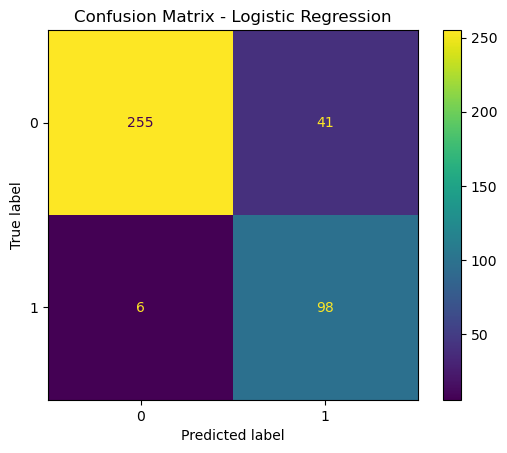

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("images/confusion_matrix.png", bbox_inches="tight")
plt.show()

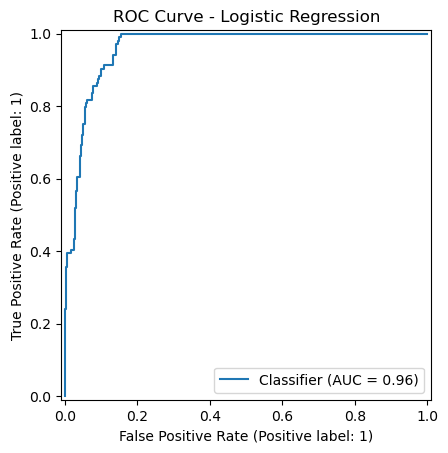

In [34]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_prob_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.savefig("images/roc_curve.png", bbox_inches="tight")
plt.show()

## Feature Importance

Feature importance helps explain which variables had the strongest influence on the outreach prioritization model.

In [35]:
rf_pipeline = trained_models["Random Forest"]

feature_names_numeric = numeric_features

feature_names_categorical = list(
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = feature_names_numeric + feature_names_categorical

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
15,care_gap,0.290915
10,diastolic_bp,0.095894
9,systolic_bp,0.081036
4,days_until_due_date,0.064779
18,measure_type_CBP_Blood_Pressure,0.057448
11,bmi,0.049682
0,age,0.048594
23,measure_type_TRC_Medication_Reconciliation,0.046133
3,has_upcoming_appointment,0.045087
22,measure_type_PPC_Postpartum_Care,0.025475


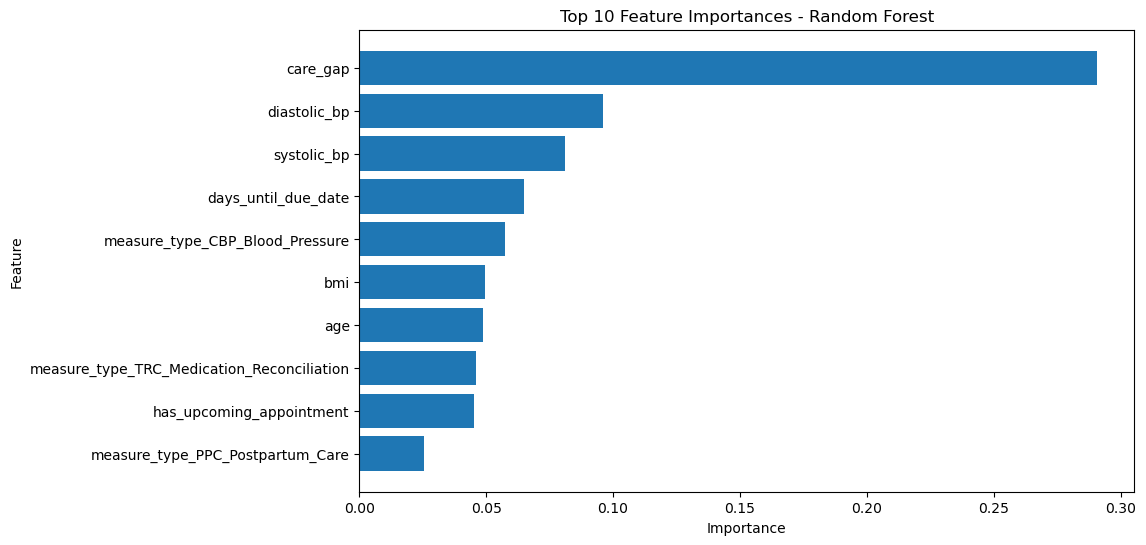

In [36]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("images/feature_importance.png", bbox_inches="tight")
plt.show()

## Outreach Priority Scoring

The model's predicted probability was converted into practical outreach priority categories:

- High priority: probability >= 0.75
- Medium priority: probability between 0.50 and 0.74
- Low priority: probability below 0.50

In [38]:
df_scored = X_test.copy()
df_scored["actual_care_gap_unresolved"] = y_test.values
df_scored["predicted_probability"] = y_prob_best

def assign_priority(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.50:
        return "Medium"
    else:
        return "Low"

df_scored["outreach_priority"] = df_scored["predicted_probability"].apply(assign_priority)

df_scored[[
    "measure_type",
    "age",
    "gender",
    "has_diabetes",
    "care_gap",
    "has_upcoming_appointment",
    "days_until_due_date",
    "prior_er_visits",
    "predicted_probability",
    "outreach_priority"
]].head(20)

,measure_type,age,gender,has_diabetes,care_gap,has_upcoming_appointment,days_until_due_date,prior_er_visits,predicted_probability,outreach_priority
1388,CBP_Blood_Pressure,30,Female,0,1,1,18,0,0.662330,Medium
1835,CBP_Blood_Pressure,43,Female,0,0,0,93,2,0.003821,Low
1979,CBP_Blood_Pressure,71,Female,0,0,0,104,1,0.002060,Low
1038,PPC_Postpartum_Care,23,Male,0,0,1,14,0,0.000742,Low
1928,EED_Eye_Exam,26,Female,1,1,1,-18,2,0.877936,High
432,PPC_Postpartum_Care,20,Male,0,0,1,83,1,0.000834,Low
1412,PPC_Postpartum_Care,31,Male,0,0,1,-22,2,0.001998,Low
1454,CBP_Blood_Pressure,68,Male,0,1,0,96,2,0.854238,High
218,PPC_Postpartum_Care,68,Female,0,0,0,7,1,0.005373,Low
1771,GSD_A1c,50,Female,1,0,0,39,0,0.003343,Low


In [39]:
def recommended_action(row):
    if row["outreach_priority"] == "High":
        if row["has_upcoming_appointment"] == 0:
            return "Call patient to schedule appointment"
        elif row["days_until_due_date"] <= 14:
            return "Verify care gap can be addressed during upcoming visit"
        else:
            return "Prioritize for care management review"
    elif row["outreach_priority"] == "Medium":
        return "Send reminder and monitor appointment status"
    else:
        return "Low priority; routine follow-up"

df_scored["recommended_action"] = df_scored.apply(recommended_action, axis=1)

df_scored[[
    "measure_type",
    "care_gap",
    "predicted_probability",
    "outreach_priority",
    "recommended_action"
]].head(20)

,measure_type,care_gap,predicted_probability,outreach_priority,recommended_action
1388,CBP_Blood_Pressure,1,0.662330,Medium,Send reminder and monitor appointment status
1835,CBP_Blood_Pressure,0,0.003821,Low,Low priority; routine follow-up
1979,CBP_Blood_Pressure,0,0.002060,Low,Low priority; routine follow-up
1038,PPC_Postpartum_Care,0,0.000742,Low,Low priority; routine follow-up
1928,EED_Eye_Exam,1,0.877936,High,Verify care gap can be addressed during upcomi...
432,PPC_Postpartum_Care,0,0.000834,Low,Low priority; routine follow-up
1412,PPC_Postpartum_Care,0,0.001998,Low,Low priority; routine follow-up
1454,CBP_Blood_Pressure,1,0.854238,High,Call patient to schedule appointment
218,PPC_Postpartum_Care,0,0.005373,Low,Low priority; routine follow-up
1771,GSD_A1c,0,0.003343,Low,Low priority; routine follow-up


In [40]:
df_scored.to_csv("hedis_outreach_scored_patients.csv", index=False)

print("Scored patient output saved successfully.")

Scored patient output saved successfully.


In [41]:
joblib.dump(best_model, "hedis_outreach_best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## Business Interpretation

This model helps population health and quality teams prioritize outreach for patients who are more likely to have unresolved care gaps.

The model can support operational decisions such as:

- Which patients should be called first
- Which patients need appointment scheduling
- Which patients may need lab completion
- Which upcoming visits should be used to close care gaps
- Which measures may need additional outreach support

This type of model could help healthcare organizations improve HEDIS performance, support value-based care initiatives, and use outreach resources more efficiently.

## Important Note

This project uses synthetic data only. No real patient data or PHI was used.